<a href="https://colab.research.google.com/github/daianx/ai201-project3-takemeter/blob/main/ai201_project3_takemeter_starter_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TakeMeter — Fine-Tuning Starter Notebook
### AI201 · Project 3

This notebook walks you through fine-tuning a text classifier on your annotated dataset and comparing it to a zero-shot baseline.

**What this notebook does for you (infrastructure):**
- Tokenizes your dataset and prepares it for training
- Runs the fine-tuning pipeline with DistilBERT
- Computes evaluation metrics and generates a confusion matrix
- Runs the Groq baseline and compares both models

**What you do (the actual work):**
- Collect and annotate your 200+ examples (done before opening this notebook)
- Define your label map and upload your CSV
- Write your Groq classification prompt using your label definitions
- Analyze the output and write your evaluation report

---
**Before you start:** Make sure you are using a T4 GPU runtime.  
Go to **Runtime → Change runtime type → T4 GPU**, then click Save.

In [1]:
# Install any dependencies not pre-installed on Colab
!pip install -q groq python-dotenv
print("✅ Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.1 MB/s eta 0:00:00
✅ Dependencies ready


In [2]:
import pandas as pd
import numpy as np
import json
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from datasets import Dataset
import warnings
warnings.filterwarnings("ignore")

print("✅ Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

✅ Imports complete
PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


---
## Section 1: Load Your Dataset

Upload your labeled CSV and define your label map.  
Your CSV must have at least two columns: `text` (the post/comment) and `label` (your string label).

In [3]:
# ── TODO ──────────────────────────────────────────────────────────────────
# Define YOUR label map below.
# Keys are the string labels in your CSV; values are integers starting at 0.
# Add or remove entries to match your actual labels (2–4 labels supported).
#
# The example below is ILLUSTRATIVE ONLY (the r/nba taxonomy from the project
# page). DELETE it and use your own community's labels — submitting the
# example unchanged will not pass.
# ────────────────────────────────────────────────────────────────────────

LABEL_MAP = {
    "analytical":  0,
    "personal":  1,
    "summary_heavy":  2,
    "reactive": 3,
}

# ── END TODO ──────────────────────────────────────────────────────────────

ID_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_LABELS = len(LABEL_MAP)
print(f"Labels: {LABEL_MAP}")
print(f"Number of labels: {NUM_LABELS}")

Labels: {'analytical': 0, 'personal': 1, 'summary_heavy': 2, 'reactive': 3}
Number of labels: 4


In [4]:
# Upload your CSV from your computer
from google.colab import files
print("Select your labeled dataset CSV file...")
uploaded = files.upload()
CSV_PATH = list(uploaded.keys())[0]
print(f"Uploaded: {CSV_PATH}")

Select your labeled dataset CSV file...


Saving dataset.csv to dataset.csv
Uploaded: dataset.csv


In [5]:
# Load and validate your dataset
df = pd.read_csv(CSV_PATH)

# ── TODO (if needed) ──────────────────────────────────────────────────────
# If your CSV uses different column names, rename them here.
# Example: df = df.rename(columns={"post": "text", "category": "label"})
# ── END TODO ──────────────────────────────────────────────────────────────

print(f"Columns: {df.columns.tolist()}")
print(f"Total examples: {len(df)}")
print()
print("Label distribution:")
print(df["label"].value_counts())

# Validate all labels are in LABEL_MAP
unknown = set(df["label"].unique()) - set(LABEL_MAP.keys())
if unknown:
    print(f"\n⚠️  Labels in CSV not found in LABEL_MAP: {unknown}")
    print("Update your LABEL_MAP above to include all labels.")
else:
    print("\n✅ All labels match your LABEL_MAP")

# Convert string labels to integers
df["label_id"] = df["label"].map(LABEL_MAP)
df = df.dropna(subset=["label_id"])
df["label_id"] = df["label_id"].astype(int)

Columns: ['book_title', 'source', 'category', 'url', 'rating', 'text', 'ai_generated_label', 'ai_reasoning', 'label', 'reasoning', 'label_2', 'difficult']
Total examples: 270

Label distribution:
label
personal         80
reactive         69
summary_heavy    64
analytical       57
Name: count, dtype: int64

✅ All labels match your LABEL_MAP


---
## Section 2: Prepare Data for Training

Splits your dataset into train / validation / test sets and tokenizes the text.

In [6]:
# Train / val / test split — 70% / 15% / 15%
# Stratified so each split has roughly the same label distribution.
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=42, stratify=df["label_id"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=42, stratify=temp_df["label_id"]
)

print(f"Train: {len(train_df)} examples")
print(f"Validation: {len(val_df)} examples")
print(f"Test: {len(test_df)} examples")
print()
print("Train label distribution:")
print(train_df["label"].value_counts())
print()
print("Test label distribution:")
print(test_df["label"].value_counts())

# Reset indices (needed for clean HuggingFace Dataset conversion)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

Train: 189 examples
Validation: 40 examples
Test: 41 examples

Train label distribution:
label
personal         56
reactive         48
summary_heavy    45
analytical       40
Name: count, dtype: int64

Test label distribution:
label
personal         12
reactive         11
summary_heavy    10
analytical        8
Name: count, dtype: int64


In [7]:
# Load tokenizer and tokenize all splits
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(examples):
    return tokenizer(examples["text"], truncation=True, max_length=256)

def make_dataset(df_split):
    ds = Dataset.from_pandas(
        df_split[["text", "label_id"]].rename(columns={"label_id": "labels"})
    )
    return ds.map(tokenize, batched=True)

train_dataset = make_dataset(train_df)
val_dataset   = make_dataset(val_df)
test_dataset  = make_dataset(test_df)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("✅ Tokenization complete")
print(f"Sample keys: {list(train_dataset[0].keys())}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/189 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Map:   0%|          | 0/41 [00:00<?, ? examples/s]

✅ Tokenization complete
Sample keys: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask']


---
## Section 3: Fine-Tune Your Model

Loads `distilbert-base-uncased` with a classification head and fine-tunes it on your training data.  
Training runs for 3 epochs and takes **5–15 minutes** on a T4 GPU.

> **Hyperparameter note:** The defaults below work well for datasets of 100–500 examples.  
> If you change any values, note what you changed and why in your README.

In [37]:
9# Load DistilBERT with a classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID_TO_LABEL,
    label2id=LABEL_MAP,
)
print(f"✅ Model loaded: {MODEL_NAME}")
print(f"Output labels: {NUM_LABELS}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded: distilbert-base-uncased
Output labels: 4


In [38]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

In [41]:
# ── Hyperparameters ───────────────────────────────────────────────────────
# num_train_epochs  — passes through the training data; 3 is a good default
#                     for small datasets. Increase cautiously; more epochs
#                     risk overfitting on 200 examples.
# learning_rate     — 2e-5 is the standard starting point for fine-tuning
#                     BERT-family models. Lower → slower but more stable.
# per_device_train_batch_size — 16 fits T4 GPU comfortably.
#                     Reduce to 8 if you get out-of-memory errors.
# ─────────────────────────────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir="./takemeter-model",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=15,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    logging_steps=10,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning... (5–15 minutes on T4 GPU)")
trainer.train()
print("\n✅ Fine-tuning complete")

Starting fine-tuning... (5–15 minutes on T4 GPU)


Epoch,Training Loss,Validation Loss,Accuracy
1,1.225059,1.243454,0.475000
2,1.166902,1.157748,0.525000
3,1.045660,1.084859,0.575000
4,0.938981,1.040744,0.600000
5,0.718254,1.012450,0.600000
6,0.641184,0.998875,0.575000
7,0.599695,0.998337,0.550000
8,0.488966,1.002906,0.550000
9,0.504179,0.992507,0.575000
10,0.420354,0.998906,0.550000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Fine-tuning complete


---
## Section 4: Evaluate Fine-Tuned Model on Test Set

Runs inference on your locked test set and generates metrics and a confusion matrix.  
These numbers go directly into your evaluation report.

In [42]:
# Run inference on the test set
print("Running inference on test set...")
ft_output = trainer.predict(test_dataset)
ft_pred_ids = np.argmax(ft_output.predictions, axis=-1)
ft_true_ids = ft_output.label_ids

ft_probs = torch.nn.functional.softmax(
    torch.tensor(ft_output.predictions), dim=-1
).numpy()

# Overall accuracy
ft_accuracy = accuracy_score(ft_true_ids, ft_pred_ids)
print(f"\n🎯 Fine-tuned model accuracy: {ft_accuracy:.3f}")

# Per-class metrics
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("\nPer-class metrics (fine-tuned model):")
print(classification_report(ft_true_ids, ft_pred_ids, target_names=label_names, zero_division=0))

Running inference on test set...



🎯 Fine-tuned model accuracy: 0.585

Per-class metrics (fine-tuned model):
               precision    recall  f1-score   support

   analytical       0.25      0.12      0.17         8
     personal       0.50      0.58      0.54        12
summary_heavy       0.62      0.80      0.70        10
     reactive       0.80      0.73      0.76        11

     accuracy                           0.59        41
    macro avg       0.54      0.56      0.54        41
 weighted avg       0.56      0.59      0.56        41



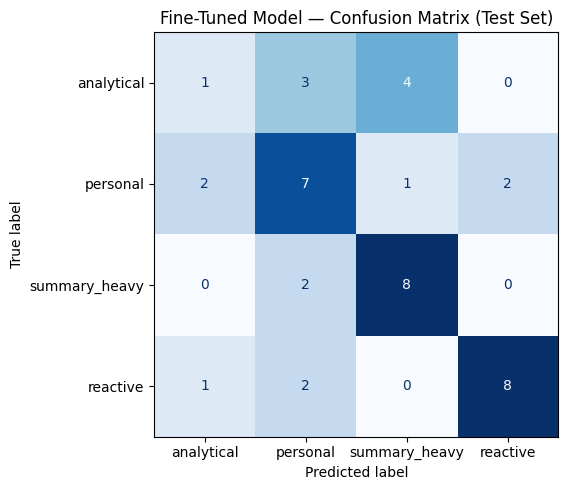

✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README


In [43]:
# Confusion matrix
cm = confusion_matrix(ft_true_ids, ft_pred_ids)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Fine-Tuned Model — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("✅ Saved: confusion_matrix.png  →  commit this to your repo and include in README")

In [44]:
# Print wrong predictions for your error analysis
# Review these carefully — pick 3 to analyze in depth in your README.

wrong_idx = np.where(ft_pred_ids != ft_true_ids)[0]
print(f"Wrong predictions: {len(wrong_idx)} / {len(ft_true_ids)}\n")

for i, idx in enumerate(wrong_idx[:15]):
    text = test_df.iloc[idx]["text"]
    true_label = ID_TO_LABEL[ft_true_ids[idx]]
    pred_label = ID_TO_LABEL[ft_pred_ids[idx]]
    confidence = ft_probs[idx][ft_pred_ids[idx]]
    print(f"--- #{i+1} ---")
    print(f"Text:      {text[:200]}{'...' if len(text) > 200 else ''}")
    print(f"True:      {true_label}")
    print(f"Predicted: {pred_label}  (confidence: {confidence:.2f})")
    print()

Wrong predictions: 17 / 41

--- #1 ---
Text:      This was everything my bookish heart could have wished for!

Rebecca Romney structured this book brilliantly! It has the perfect amount of literary history, informative insights, interesting commentar...
True:      analytical
Predicted: personal  (confidence: 0.40)

--- #2 ---
Text:      Stephen King delivers another sharp, character driven thriller with Never Flinch, and I really enjoyed it. It’s a slower burn than some of his earlier work, but it’s packed with tension, moral questio...
True:      analytical
Predicted: summary_heavy  (confidence: 0.37)

--- #3 ---
Text:      This is very detailed at points, excruciatingly so. If you are a survivor, this could trigger you. It didn’t me…I found comfort in recognizing how own my trauma has had a lasting effect on my marriage...
True:      personal
Predicted: reactive  (confidence: 0.54)

--- #4 ---
Text:      Okay, this book? Chef’s kiss. Carley Fortune just gets it, those messy, beautifu

---
## Section 5: Baseline Classifier (Groq)

Runs your zero-shot baseline using `llama-3.3-70b-versatile`.  
You need to write the classification prompt using your label definitions.

In [12]:

from groq import Groq

# ── TODO: Add your Groq API key ───────────────────────────────────────────
# Recommended: use Colab Secrets so your key is never visible in the notebook.
#   1. Click the 🔑 icon in the left sidebar ("Secrets")
#   2. Add a secret named GROQ_API_KEY with your key as the value
#   3. Enable notebook access for the secret
#
# Then uncomment Option A below (and delete Option B).
#
# Option A — Colab Secrets (recommended):
from google.colab import userdata
GROQ_API_KEY = userdata.get("GROQ_API_KEY")
#
# Option B — paste directly (do not commit to GitHub):
#GROQ_API_KEY = "your_groq_api_key_here"

assert GROQ_API_KEY, (
    "GROQ_API_KEY not set — add it in the Colab Secrets panel (\U0001f511, left "
    "sidebar) and enable notebook access for this notebook, or use Option B above."
)

client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

✅ Groq client initialized


In [13]:
# ── TODO: Write your classification prompt ────────────────────────────────
# Your prompt should:
#   1. Name your community and task
#   2. Define each label in plain language (copy from your planning.md)
#   3. Give one example post per label
#   4. Tell the model to output ONLY the label name — nothing else
#
# The model's response must match one of your label strings exactly,
# or the classify_with_groq() function below will mark it as unparseable.
#
# ─────────────────────────────────────────────────────────────────────────
# REPLACE the placeholders below with your actual prompt. As written, this
# skeleton will NOT classify correctly — you must fill it in.

SYSTEM_PROMPT = """
You are classifying book reviews from the online book reviewing community (Goodreads, StoryGraph, LibraryThing).
Assign each post to exactly one of the following categories which best fits the post.

analytical: The review discusses craft observations such as pacing, prose style, narrative structure, character development, thematic content, book length or how this book compares to the author's other work or similar books. The central argument is about *what the book does and how well it does it*, not primarily about how the reader felt reading it.
Example: "The pacing in the second act dragged significantly, but the author's use of non-linear narrative effectively mirrored the protagonist's fracturing psyche. The thematic exploration of grief was well-supported by the recurrent water motifs."

personal: The review centers the reader's emotional or biographical response: how the book affected them, what it reminded them of, how it connects to their life. Specific to the reader, not a craft argument. The review may express strong feeling, but the feeling is grounded in a particular personal anchor: a memory, a relationship, a life circumstance, or a deeply specific emotional reaction tied to the reviewer's experience.
Example: "This book reminded me so much of my grandmother. I cried for hours because the main character's journey perfectly mirrored my own childhood trauma. It felt like the author was reading my diary."

summary_heavy: The review is primarily plot retelling with minimal evaluative content. Often "here's what happens" with a brief verdict tacked on at the end.
Example: "Sarah moves to a new town and meets a mysterious boy named John. They discover a secret portal in the woods. Then they have to fight a dragon to save her little brother. It was an okay read, 3 stars."

reactive: The review is a polarized, uncritical take — strong positive or negative without elaboration or personal grounding. Star ratings narrated as prose, hype reactions, emojis, and rage-quit posts fall here.
Example: "OMFG I am literally screaming crying throwing up. BEST BOOK EVER WRITTEN 5000 STARS!!! I will never recover from this."

Edge case decision rules:
1. reactive vs personal:
- A personal review must be anchored to some personal experience or life event. "This reminded me of the year my mother stopped recognizing me" is personal.
- Quick test: Could this sentence appear in a review of any emotionally resonant book, by any reader? If yes, reactive. If the specificity makes it this reader's review, personal.

2. analytical vs summary_heavy:
- If the summary is used to support a craft claim, it's analytical. If the summary exists on its own with only a verdict attached, it's summary_heavy.
- Strip test: Remove the plot sentences. If an evaluative argument remains, it's analytical. If what's left is a one-line verdict or nothing, it's summary_heavy.

3. analytical vs personal hybrids:
- The distinction is about who the argument is addressed to. analytical reviews make claims a third party could evaluate. personal reviews make claims only the reviewer can verify.
- Strip test: Remove "I" sentences. If a craft argument survives, it's analytical; if only impressions remain, it's personal.

4. reactive vs summary_heavy:
- reactive reviews declare a verdict at high emotional intensity. summary_heavy reviews describe what the book contains at low emotional intensity.
- Quick test: Is the dominant register intensity or description? Intensity → reactive. Description → summary_heavy.

5. personal vs summary_heavy:
- Ask what the review is about. If plot is the frame and personal experience the point, it's personal. If reactions are just color commentary on a plot walkthrough, it's summary_heavy.
- Quick test: Remove plot sentences. If you still understand why the book mattered to this reviewer, it's personal. If almost nothing remains, it's summary_heavy.

6. reactive vs analytical:
- A craft observation only qualifies as analytical if it is arguable and supported — meaning a reader could examine the evidence and agree or disagree. A label without evidence is reactive, even if it uses craft vocabulary.
- Quick test: Could a reader push back on this claim with evidence from the book? If the claim is specific enough to be disputed, it's analytical. If it's a verdict dressed in craft language, it's reactive.


Respond with ONLY the label name.
Do not explain your reasoning.

Valid labels:
analytical
personal
summary_heavy
reactive
"""

print("Prompt length:", len(SYSTEM_PROMPT), "characters")

Prompt length: 4492 characters


In [14]:
def classify_with_groq(text):
    """Classify a single post. Returns a label string or None if unparseable."""
    try:
        response = client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Classify this post:\n\n{text}"},
            ],
            temperature=0,
            max_tokens=20,
        )
        raw = response.choices[0].message.content.strip().lower()
        # Match the model's output to a label. Check longest labels first so a
        # label that is a substring of another (e.g. "recommendation" vs.
        # "strong_recommendation") can't be matched by mistake.
        for label in sorted(LABEL_MAP, key=len, reverse=True):
            if raw == label or label in raw:
                return label
        return None  # model output didn't match any known label
    except Exception as e:
        print(f"API error: {e}")
        return None


# Run baseline on test set
print(f"Running baseline on {len(test_df)} examples...")
print("(May take a few minutes — 0.1s delay between requests to respect free-tier limits)\n")

baseline_preds = []
for i, (_, row) in enumerate(test_df.iterrows()):
    pred = classify_with_groq(row["text"])
    #print(pred)
    baseline_preds.append(pred)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{len(test_df)} complete...")
    time.sleep(0.1)

none_count = baseline_preds.count(None)
if none_count > 0:
    print(f"\n⚠️  {none_count} responses could not be parsed.")
    print("Review your prompt — the model may not be outputting clean label names.")

Running baseline on 41 examples...
(May take a few minutes — 0.1s delay between requests to respect free-tier limits)

  10/41 complete...
  20/41 complete...
  30/41 complete...
  40/41 complete...


In [15]:
12# Baseline metrics (exclude unparseable responses)
valid = [(p, t) for p, t in zip(baseline_preds, test_df["label_id"])
         if p is not None]
bl_pred_ids = [LABEL_MAP[p] for p, _ in valid]
bl_true_ids = [t for _, t in valid]

bl_accuracy = accuracy_score(bl_true_ids, bl_pred_ids)
print(f"🎯 Baseline accuracy: {bl_accuracy:.3f}  "
      f"(evaluated on {len(valid)}/{len(test_df)} parseable responses)")
print()
label_names = [ID_TO_LABEL[i] for i in range(NUM_LABELS)]
print("Per-class metrics (baseline):")
print(classification_report(bl_true_ids, bl_pred_ids, target_names=label_names, zero_division=0))

🎯 Baseline accuracy: 0.390  (evaluated on 41/41 parseable responses)

Per-class metrics (baseline):
               precision    recall  f1-score   support

   analytical       0.26      0.75      0.39         8
     personal       0.43      0.25      0.32        12
summary_heavy       0.00      0.00      0.00        10
     reactive       0.88      0.64      0.74        11

     accuracy                           0.39        41
    macro avg       0.39      0.41      0.36        41
 weighted avg       0.41      0.39      0.37        41



---
## Section 6: Compare Results and Export

Side-by-side comparison of both models.  
Download the output files and commit them to your GitHub repo.

In [45]:
print("=" * 50)
print("RESULTS COMPARISON")
print("=" * 50)
print(f"{'Model':<35} {'Accuracy':>8}")
print("-" * 45)
print(f"{'Zero-shot baseline (Groq)':<35} {bl_accuracy:>8.3f}")
print(f"{'Fine-tuned DistilBERT':<35} {ft_accuracy:>8.3f}")
print("-" * 45)
delta = ft_accuracy - bl_accuracy
direction = "improvement" if delta >= 0 else "regression"
print(f"\nFine-tuning {direction}: {abs(delta):.3f}")
print()
print("Use these numbers in your README evaluation report.")

RESULTS COMPARISON
Model                               Accuracy
---------------------------------------------
Zero-shot baseline (Groq)              0.390
Fine-tuned DistilBERT                  0.585
---------------------------------------------

Fine-tuning improvement: 0.195

Use these numbers in your README evaluation report.


In [46]:
# Save results JSON — commit to your GitHub repo and reference in README
results = {
    "baseline_accuracy": round(bl_accuracy, 4),
    "finetuned_accuracy": round(ft_accuracy, 4),
    "improvement": round(ft_accuracy - bl_accuracy, 4),
    "test_set_size": len(test_df),
    "label_map": LABEL_MAP,
    "model": MODEL_NAME,
}
with open("evaluation_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("✅ Files ready to download:")
print("   evaluation_results.json  — metrics for your README")
print("   confusion_matrix.png     — include in your README")
print()
print("Download via: Files panel (📁) on the left → right-click → Download")

✅ Files ready to download:
   evaluation_results.json  — metrics for your README
   confusion_matrix.png     — include in your README

Download via: Files panel (📁) on the left → right-click → Download


## Inter-Annotator Reliability

Uses 36 label_2 values for comparison

In [47]:
!pip install gradio torch transformers

In [48]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score, accuracy_score

# Load your dataset (make sure the filename matches what you uploaded)
df_iar = pd.read_csv(CSV_PATH)

# Filter to only the rows where the second annotator provided a label
df_iar_clean = df_iar.dropna(subset=['label', 'label_2']).copy()

# Standardize text (lowercase and strip spaces) just in case of typos
labels_1 = df_iar_clean['label'].astype(str).str.strip().str.lower()
labels_2 = df_iar_clean['label_2'].astype(str).str.strip().str.lower()

# Calculate the metrics
agreement = accuracy_score(labels_1, labels_2)
kappa = cohen_kappa_score(labels_1, labels_2)

print(f"Number of dually-annotated examples: {len(labels_1)}")
print(f"Percentage Agreement: {agreement * 100:.1f}%")
print(f"Cohen's Kappa: {kappa:.3f}\n")

# Print the specific disagreements to help you write your README analysis
print("**DISAGREEMENTS FOR ERROR ANALYSIS**")
disagreements = df_iar_clean[labels_1 != labels_2]
for i, row in disagreements.iterrows():
    text = str(row.get('text', ''))
    print(f"Text: {text[:150]}...")
    print(f"I labeled: {row['label']}  |  They labeled: {row['label_2']}")
    print("\n")

Number of dually-annotated examples: 36
Percentage Agreement: 69.4%
Cohen's Kappa: 0.588

**DISAGREEMENTS FOR ERROR ANALYSIS**
Text: (1.5 stars) In this book, a girl named Louisa runs into her idol, the world famous artist who created her favorite painting. The artist dies and sends...
I labeled: analytical  |  They labeled: reactive


Text: I get the hype. But this one was just too broken for me and I didn’t need to feel that many sad things right now. ...
I labeled: reactive  |  They labeled: personal


Text: I have a like/love relationship with Fredrick Backman’s books. Some I like, some I like a lot, some I love, and some just blow me out of the water. “M...
I labeled: analytical  |  They labeled: personal


Text: OMGGGGGG TJR is just a treasure 🥹🤍🚀📖

this kinda wasn’t what i expected at ALL but of course i’m in awe. the last 20 pages had me so teary eyed!!!! he...
I labeled: reactive  |  They labeled: personal


Text: Was a fine read - easy writing style, but shocker to noone, thi

## Confidence Calibration



In [49]:
# Create confidence bins (50-60%, 60-70%, etc.)
confidences = np.max(ft_probs, axis=1)
correct_preds = (ft_pred_ids == ft_true_ids)

print("Confidence Calibration:")
for lower in range(20, 100, 10):
    upper = lower + 10
    mask = (confidences >= lower/100.0) & (confidences < upper/100.0)
    if np.sum(mask) > 0:
        bin_acc = np.mean(correct_preds[mask])
        print(f"Confidence {lower}-{upper}%: Model is accurate {bin_acc*100:.1f}% of the time ({np.sum(mask)} examples)")

Confidence Calibration:
Confidence 30-40%: Model is accurate 33.3% of the time (12 examples)
Confidence 40-50%: Model is accurate 61.9% of the time (21 examples)
Confidence 50-60%: Model is accurate 83.3% of the time (6 examples)
Confidence 60-70%: Model is accurate 100.0% of the time (2 examples)


## Interface

In [ ]:
!pip install sentencepiece tiktoken

In [51]:
import gradio as gr
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# Detect if a GPU is available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Ensure this directory matches the folder you downloaded/saved from Colab training
MODEL_DIR = "./takemeter-model/checkpoint-48"
LOAD_ERROR = None

try:
    print(f"Loading model from {MODEL_DIR}...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)

    # Move model to the correct device (GPU if available)
    model.to(device)

    # Set model to evaluation mode (disables dropout for consistent predictions)
    model.eval()
    print(f"✅ Model loaded successfully on {device}!")
except Exception as e:
    LOAD_ERROR = str(e)
    print(f"❌ Error loading model: {e}")
    print("Please make sure you have run the training cells and the 'takemeter-model' folder exists.")
    tokenizer = None
    model = None

def classify_review(text):
    """Takes a string input, runs it through the fine-tuned model, and returns a dictionary of confidences."""
    if not text or not text.strip():
        return {"Please enter text": 0.0}

    if model is None or tokenizer is None:
        # If it fails, this will display the specific error right in the Gradio UI
        return {"Error Loading Model": 1.0, "Did you restart Colab runtime?": 0.0}

    # Tokenize the input text exactly how we did in Colab (max 512 tokens)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)

    # CRITICAL FIX: Move inputs to the exact same device as the model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Run inference without tracking gradients (saves memory and speeds up prediction)
    with torch.no_grad():
        outputs = model(**inputs)

    # Convert logits to probabilities using Softmax, moving back to CPU so numpy can read them
    probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1).squeeze().cpu().numpy()

    # Map the probabilities to our label names for the Gradio interface
    # (Ensure these match your LABEL_MAP exactly)
    labels = ["Analytical", "Personal", "Summary_heavy", "Reactive"]

    # Create a dictionary of {label: probability}
    # Gradio's Label component uses this format to create the confidence bars
    result = {label: float(prob) for label, prob in zip(labels, probabilities)}
    return result

# Create the Gradio interface
interface = gr.Interface(
    fn=classify_review,
    inputs=gr.Textbox(lines=5, placeholder="Paste a book review here...", label="Review Text"),
    outputs=gr.Label(num_top_classes=4, label="Predicted Category"),
    title="TakeMeter: Book Review Classifier",
    description="Paste a Goodreads, StoryGraph, or LibraryThing review to see how the fine-tuned DistilBERT model classifies it.",
    theme="default"
)

if __name__ == "__main__":
    # Launch the interface with a public link (great for Google Colab)
    interface.launch(share=True, debug=True)

Loading model from ./takemeter-model/checkpoint-48...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Model loaded successfully on cuda!
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8b801b56ca89e286ee.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://8b801b56ca89e286ee.gradio.live
